# 공공 데이터

> 강원도_화재위험 및 안전시설조사 : https://www.data.go.kr/data/15096632/fileData.do  

##### GIS 기반의 교통량 분석
> http://taas.koroad.or.kr/web/shp/sbm/initGisAnals.do?menuId=WEB_KMP_GIS_TAS

교통사고 다발지역 , 교통사고 빅데이터 분석을 이욯해서 데이터 생성  
tc_accident db가 있음  
![](https://i.imgur.com/bx8sbYK.jpg)


## 강원도_화재위험 및 안전시설 조사
어떤 방식으로 처리?

In [2]:
%config Completer.use_jedi = False

In [16]:
import geopandas as gpd
import matplotlib.pyplot as plt

In [41]:
fire = gpd.read_file('./fire/강원도_화재위험 및 안전시설 조사.shx')
fire.columns

Index(['건물번호', '사용_량', 'PNU', '공시지가', '면적', '건통번호', '건축물용도', '건축물구조', '건축물면적',
       '대지면적', '높이', '건폐율', '용적율', '지상층수', '지하층수', '건축면적', '구조', '지역구분',
       '건물연면적', '주요용도명', '건물높이', '건물연령', '스프링쿨러', '소화기', '화재감지기', '업태',
       'geometry'],
      dtype='object')

In [42]:
fire

,건물번호,사용_량,PNU,공시지가,면적,건통번호,건축물용도,건축물구조,건축물면적,대지면적,...,지역구분,건물연면적,주요용도명,건물높이,건물연령,스프링쿨러,소화기,화재감지기,업태,geometry
0,4283033029105080000000002,NaN,None,NaN,NaN,None,기타판매및영업시설,None,NaN,NaN,...,일반군,NaN,기타판매및영업시설,NaN,NaN,무,유,무,해양관광시설_서핑,"POLYGON ((1106829.333 2003795.074, 1106843.444..."
1,4283034021106340006000001,1505.833333,None,NaN,247.1,None,단독주택,일반철골구조,97.60,247.1,...,일반군,97.60,단독주택,4.50,5.0,무,유,무,해양관광시설_서핑,"POLYGON ((1110795.277 1997329.957, 1110791.632..."
2,4283032025100230004000004,751.875000,None,NaN,NaN,None,휴양콘도미니엄,철근콘크리트구조,3214.58,NaN,...,일반군,6503.73,휴양콘도미니엄,28.20,27.0,유,유,유,해양관광시설_서핑,"POLYGON ((1102328.033 2010345.508, 1102316.616..."
3,4282033021101110000014224,13583.333333,None,NaN,NaN,None,휴게음식점,경량철골구조,54.74,NaN,...,일반군,54.74,휴게음식점,4.20,5.0,무,무,무,해양관광시설_서핑,"POLYGON ((1092733.453 2029430.106, 1092729.606..."
4,4283033022101430004007177,1399.833333,None,NaN,971.0,None,일반공장,일반철골구조,350.93,971.0,...,일반군,407.65,일반공장,10.40,23.0,무,유,무,해양관광시설_서핑,"POLYGON ((1107932.129 2001315.416, 1107911.247..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
493,4215011000118320002001397,NaN,4215011000118320000,720900.0,218.0,2004189164774739101800000000,일반음식점,철근콘크리트구조,130.43,218.0,...,일반시,353.48,일반음식점,10.85,18.0,무,무,무,다중이용시설_음식점,"POLYGON ((1121340.166 1975116.160, 1121338.790..."
494,4215011000118250002020511,7339.833333,4215011000118250000,1537000.0,321.4,2003189253044739606800000000,학원,철근콘크리트구조,207.52,321.4,...,일반시,796.68,학원,18.05,19.0,무,유,유,다중이용시설_음식점,"POLYGON ((1121428.329 1975156.503, 1121427.949..."
495,4215011000118240001028345,6580.916667,4215011000118240000,1464000.0,354.0,2001189270544740663100000000,일반음식점,철근콘크리트구조,144.78,354.0,...,일반시,811.93,일반음식점,18.30,21.0,무,유,무,다중이용시설_음식점,"POLYGON ((1121442.531 1975274.315, 1121442.120..."
496,4215011000118270003000001,NaN,None,NaN,382.2,None,다가구주택,철근콘크리트구조,225.81,382.2,...,일반시,494.41,다가구주택,11.10,11.0,무,유,무,다중이용시설_음식점,"POLYGON ((1121488.622 1975239.775, 1121506.442..."


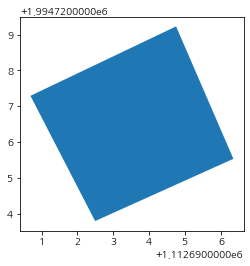

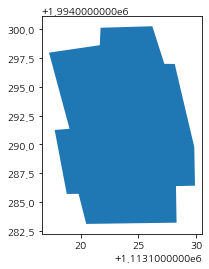

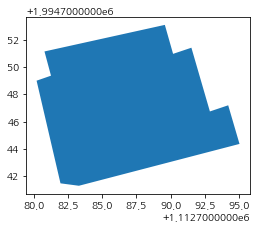

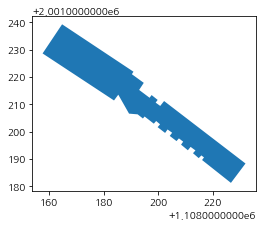

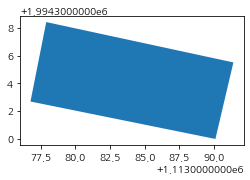

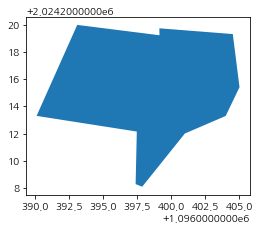

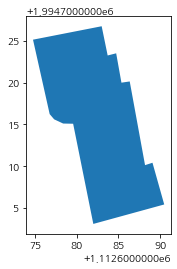

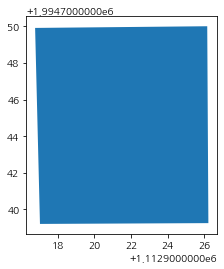

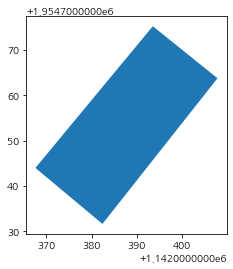

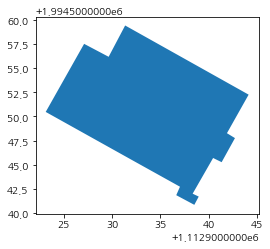

In [39]:
plt.rcParams['figure.figsize']=(4,4)
for i in range(20,30):
    fire['geometry'][i:i+1].plot()
    plt.show()
    

# data search
내부 연계 데이터와 외부연계 데이터 확인후 모델에 추가적으로 넣을 데이터 확인  

In [3]:
# resact function
import mariadb
import sys
import pandas as pd
import datetime
import itertools
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'NanumGothic'


def get_csv(table_name, gugun='춘천시'):
    try:
        conn = mariadb.connect(
        user = "root",
        password = "133nplab",
        host = "localhost",
        port = 3306,
        database = "TC"
        )
    except mariadb.Error as e:
        print(e)
        
    cur = conn.cursor()
    sql_query = "SELECT * from " + table_name
    cur.execute(sql_query)
    rows = cur.fetchall()
    table_query = "DESC " + table_name
    cur.execute(table_query)
    schema = cur.fetchall()
    columns = [name[0] for name in schema]
    recs = [rec for rec in rows]
    df = pd.DataFrame(recs,columns=columns)
    return df

# 내부 연계 데이터

내부 데이터중에서 사용할만한 db만을 선택  
사용할 때는 면적 + 빈도수를 이용해서 사용?    

In [10]:
spsft = get_csv('tc_spsft_mngmn')
spsft[:10]

,SEQ,OBJ_STAT,FSTNSMALL_NM,BSNS_NM,DSR_ADDR,ROAD_NM_ADDR,OBJ_NM,BSNS_AREA,TOTAR,BSNS_OWNM,...,RGSTR_MTHD,INSRN_RGSTR,PRBTN,GRID_S_CD,GRID_L_CD,STDG_CD,CLCT_STAT_CD,CLCT_DTIME,CLCT_SERIAL_NO,ROW_IDX
0,1,정상,횡성소방서/횡성119안전센터,횡성장례문화센터식당,강원도 횡성군 횡성읍 학곡리 137-0번지,학오로 56-0 장례문화센터,None,718.2,1442.4,,...,수기등록,정상,None,None,None,T-0,C000,20220101041602,20220101041505,1
1,2,정상,횡성소방서/횡성119안전센터,대성장례센터,강원도 횡성군 횡성읍 입석리 135-3번지,횡성로 273-0 장례식장,None,246.49,1610.22,,...,민원접수,정상,None,None,None,T-0,C000,20220101041602,20220101041505,2
2,3,정상,횡성소방서/횡성119안전센터,하랑스카이,강원도 횡성군 횡성읍 읍하리 81-3번지,태기로 16-0 진타워,None,104.96,1131.28,,...,민원접수,정상,None,None,None,T-0,C000,20220101041602,20220101041505,3
3,4,정상,횡성소방서/횡성119안전센터,몰디브뮤직타운,강원도 횡성군 횡성읍 읍하리 73-8번지,삼일로 11-0,None,76.95,153.9,,...,수기등록,정상,None,None,None,T-0,C000,20220101041602,20220101041505,4
4,5,정상,횡성소방서/횡성119안전센터,향교웨딩홀,강원도 횡성군 횡성읍 읍하리 531-13번지,읍하남로13번길 2-0,None,674.78,674.78,,...,수기등록,정상,None,None,None,T-0,C000,20220101041602,20220101041505,5
5,6,정상,횡성소방서/횡성119안전센터,그랜드노래연습장,강원도 횡성군 횡성읍 읍하리 524-3번지,문화체육로 54-0,None,186.44,867.33,,...,민원접수,정상,None,None,None,T-0,C000,20220101041602,20220101041505,6
6,7,정상,횡성소방서/횡성119안전센터,뽀뽀뽀노래연습장,강원도 횡성군 횡성읍 읍하리 509-7번지,읍하남로13번길 41-0,None,143.4,408,,...,수기등록,정상,None,None,None,T-0,C000,20220101041602,20220101041505,7
7,8,정상,횡성소방서/횡성119안전센터,운동장노래연습장,강원도 횡성군 횡성읍 읍하리 509-1번지,문화체육로 36-0,None,176.85,887.78,,...,수기등록,정상,None,None,None,T-0,C000,20220101041602,20220101041505,8
8,9,정상,횡성소방서/횡성119안전센터,롯데리아횡성점,강원도 횡성군 횡성읍 읍하리 473-36번지,문정로 25-0,None,218.64,218.64,,...,민원접수,정상,None,None,None,T-0,C000,20220101041602,20220101041505,9
9,10,폐업,횡성소방서/횡성119안전센터,횡성스크린골프,강원도 횡성군 횡성읍 읍하리 413-2번지,앞들서로 2-0 --,None,220.1,659.74,,...,수기등록,만기,None,None,None,T-0,C000,20220101041602,20220101041505,10


In [5]:
get_csv('tc_buldsta')

,SEQ,OBJ_MANAGE_NO,OBJ_TYPE_NM,OBJ_STDR_NM,FSTNSMALL_NM,FSTNSMALL_CNTER,OBJ_NM,MAIN_PRPOS,PARTCPNT_NM,LOTNO_ADDR,...,ONSLF_CHCK_TAGET_AT,PBLINSTT_YN,LGZ_FIRE_FRGLTY_TRGET_YN,GRID_S_CD,GRID_L_CD,STDG_CD,CLCT_STAT_CD,CLCT_DTIME,CLCT_SERIAL_NO,ROW_IDX
0,1,42800202000000508,일반대상,일반대상물,양구소방서,양구119안전센터,강원도 양구군 동면 임당리 25\n\n분뇨쓰레기,자원순환관련시설,None,강원도 양구군 동면 임당리 25,...,None,N,None,None,라아4821,4280032025,C000,20220101034535,20220101034505,1
1,2,42130201000000505,2급대상,옥내소화전설치대상,원주소방서,기업119안전센터,(주)금돈- 돼지문화원,복합건축물,None,강원도 원주시 지정면 월송리 338-19,...,Y,N,None,None,라사3232,4213033026,C000,20220101034535,20220101034505,2
2,3,42150200600037316,3급대상,자동화재탐지설치대상,강릉소방서,주문진119안전센터,"(주)정필 ,구,대원수산",공장,김성열,강원도 강릉시 주문진읍 교항리 1207-8,...,None,N,None,None,마사1686,4215025022,C000,20220101034535,20220101034505,3
3,4,42770202000001441,일반대상,일반대상물,정선소방서,신동119안전센터,가사리 산112-6(1팀),창고시설,None,강원도 정선군 신동읍 가사리 (산) 112-6,...,None,N,None,None,마사0318,4277025925,C000,20220101034535,20220101034505,4
4,5,42130200800000881,일반대상,일반대상물,원주소방서,명륜119안전센터,간이역 (구 J KIDS),근린생활시설,None,강원도 원주시 명륜동 841-8,...,None,N,None,None,라사3925,4213010600,C000,20220101034535,20220101034505,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96777,96778,42170201400001398,일반대상,일반대상물,동해소방서,묵호119안전센터,힐하우스(유명열 복합건축물),복합건축물,유명열,강원도 동해시 어달동 45,...,None,N,None,None,마사4253,4217012700,C000,20220101034600,20220101034505,96778
96778,96779,42190201600000003,3급대상,자동화재탐지설치대상,태백소방서,황지119안전센터,힐하우스모텔(휴업),복합건축물,임성준,강원도 태백시 황지동 400-5 힐하우스모텔,...,Y,N,None,None,마사3107,4219010100,C000,20220101034600,20220101034505,96779
96779,96780,42150201400003841,일반대상,일반대상물,강릉소방서,포남119안전센터,"힘찬어린이체육교실(구,중원건설(주))",근린생활시설,김종순,강원도 강릉시 병산동 279-2,...,None,N,None,None,마사2775,4215012900,C000,20220101034600,20220101034505,96780
96780,96781,42720201400005108,일반대상,일반대상물,홍천소방서,서석119안전센터,舊 동두분교(철거),교육연구시설,유왕남,강원도 홍천군 서석면 청량리 309-2,...,None,N,None,None,라사6263,4272034026,C000,20220101034600,20220101034505,96781


In [6]:
get_csv('tc_danger')

,SEQ,FSTNSMALL_NM,MNFCTRECT_NM,OBJ_NM,DAN_SAFE_NM,INSTLR_NM,INSTLR_BIRTH,TELNO,ANTY_MUL_SM,PRMISN_NO,...,SUBAE_YN,LOTNO_ADDR,ROAD_NM_ADDR,GRID_S_CD,GRID_L_CD,STDG_CD,CLCT_STAT_CD,CLCT_DTIME,CLCT_SERIAL_NO,ROW_IDX
0,1,고성소방서/거진119안전센터,주유취급소,거진OK주유소,김정수(20210709/010-2008-6274),김정수,1978-03-17,010-2008-6274,206,00009,...,N,강원도 고성군 거진읍 거진리 423-214,거탄진로 28,None,,,C000,20220101031510,20220101031506,1
1,2,양양소방서/강현119안전센터,이동탱크저장소,낙산주유소,None,(주)낙산주유소 김수민,144511-0012231,033-672-2871,9,00266,...,N,강원도 양양군 강현면 주청리 99-1,주청1길 8,None,라아9813,4283035040,C000,20220101031510,20220101031506,2
2,3,강릉소방서/옥계119안전센터,이동탱크저장소,정동진 주유소,None,유재선,1964-01-11,033-644-5053,1.38,01304,...,N,강원도 강릉시 강동면 정동진리 291-10,헌화로 1073 --,None,마사3566,4215034028,C000,20220101031510,20220101031506,3
3,4,강릉소방서/유천119안전센터,이동탱크저장소,GS교동택지주유소,None,최재현,1967-06-16,010-5362-0209,1.5,01279,...,N,강원도 강릉시 교동 1814-2,하슬라로 233,None,마사2175,4215011000,C000,20220101031510,20220101031506,4
4,5,강릉소방서/유천119안전센터,이동탱크저장소,None,None,강원물류(주) 강원물류(주),141111-0058723,033-651-8859,120,01297,...,N,강원도 강릉시 유천동 535-2,사임당로 328,None,마사1975,4215013100,C000,20220101031510,20220101031506,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6040,6041,원주소방서/예방안전과,이동탱크저장소,None,None,(주)유일자동차판매 대표이사,120111-0320771,017-206-1832,9.8,02641,...,N,인천광역시 남구 학익동 587-58 (주)유일자동차판매,,None,,,C000,20220101031512,20220101031506,6041
6041,6042,마산소방서/구암119안전센터,이동탱크저장소,84머7875,None,(주)강토 대표이사,171211-0049633,055-255-2828,15,01216,...,N,경상남도 창원시 마산회원구 합성동 162-28,한성주유소,None,,,C000,20220101031512,20220101031506,6042
6042,6043,충주소방서/주덕119안전센터,주유취급소,None,None,주미숙\n,1967-02-28,043-848-8626\n,260,00031,...,N,"충청북도 충주시 신니면 광월리 650-2 수월주유소(전, 청도주유소)","수월주유소(전, 청도주유소)",None,,,C000,20220101031512,20220101031506,6043
6043,6044,마산소방서/예방안전과,옥외저장소,성동산업(주)마산조선소,None,성동산업(주) 마산조선소 대표이사,184511-0011376,055-259-7119,20,01214,...,N,경상남도 창원시 마산회원구 양덕동 974-15,,None,,,C000,20220101031512,20220101031506,6044


# 외부 연계 데이터
사용할만한 db만을 가져옴  

In [8]:
get_csv('tc_census')

,SEQ,STD_YEAR,ADMDSP_CD,ADMDSP_NM,AGE_IDX,AVG_AGE,AVG_FMEMBER_CNT,BIZ_CNT,EMP_CNT,PPLTN_DNSTY,TOT_FAMILY,TOT_HOUSE,TOT_PPLTN,GRID_S_CD,GRID_L_CD,STDG_CD,CLCT_STAT_CD,CLCT_DTIME,CLCT_SERIAL_NO,ROW_IDX
0,9054,2021,3200000,None,None,None,None,None,None,None,None,None,None,None,None,4200000000,None,None,None,None
1,9055,2021,3201000,None,None,None,None,None,None,None,None,None,None,None,None,4211000000,None,None,None,None
2,9056,2021,3201053,None,None,None,None,None,None,None,None,None,None,None,None,4211011000,None,None,None,None
3,9057,2021,3201063,None,None,None,None,None,None,None,None,None,None,None,None,4211011000,None,None,None,None
4,9058,2021,3201058,None,None,None,None,None,None,None,None,None,None,None,None,4211011000,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
937,10481,2016,3241031,강원도 양양군 서면,495.6,52.8,2.1,341,1237,10.4,1239,1147,2773,None,None,4283031000,C000,20211130152725,20211130152700,None
938,10482,2016,3241032,강원도 양양군 손양면,530.4,52.6,2.1,284,1252,46.3,1025,922,2210,None,None,4283032000,C000,20211130152725,20211130152700,None
939,10483,2016,3241033,강원도 양양군 현북면,422.1,52.9,2,343,752,15.4,1249,1176,2536,None,None,4283033000,C000,20211130152725,20211130152700,None
940,10484,2016,3241034,강원도 양양군 현남면,679.9,55.8,2,453,1238,44.5,1402,1301,2896,None,None,4283034000,C000,20211130152725,20211130152700,None


In [10]:
get_csv('tc_event')

,SEQ,STD_YEAR,EVENT_NM,ATPN_DESC,ENTNC_AGE,EVENT_DESC,EVENT_END_DTIME,EVENT_BGNG_DTIME,LATITUDE,LONGITUDE,...,OPAR,REFERENCE_DTIME,SEAT_CNT,GRID_S_CD,GRID_L_CD,STDG_CD,CLCT_STAT_CD,CLCT_DTIME,CLCT_SERIAL_NO,ROW_IDX
0,1,2021,박경리 이야기쇼,,8세이상,음악과 문학이 함께하는 이야기 쇼(토크쇼),202111201600,202111201400,37.32276957,127.9597297,...,박경리 문학의 집 5층,20210901,20,None,라사4024,4213010700,C000,20220106172524,20220106172515,1
1,2,2021,원주시립합창단 제96회 정기연주회,,8세이상,합창 공연,202109302130,202109301930,37.34192499,127.9197228,...,원주백운아트홀,20210831,962,None,라사3727,4213011500,C000,20220106172524,20220106172515,2
2,3,2021,원주시립교향악단 제149회 정기연주회,,8세이상,클래식 연주회,202110282130,202110281930,37.34192499,127.9197228,...,원주백운아트홀,20210831,962,None,라사3727,4213011500,C000,20220106172524,20220106172515,3
3,4,2021,원주시립교향악단 제150회 정기연주회,,8세이상,클래식 연주회,202111262130,202111261930,37.34192499,127.9197228,...,원주백운아트홀,20210831,962,None,라사3727,4213011500,C000,20220106172524,20220106172515,4
4,5,2021,원주시립예술단 정기연주회,,8세이상,클래식 연주회,202112152130,202112151930,37.34192499,127.9197228,...,원주백운아트홀,20210831,962,None,라사3727,4213011500,C000,20220106172524,20220106172515,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154,155,2021,코리안심포니오케스트라와 만나는 영화음악 시네마클래식 데이,,만7세이상,공연,202109142130,202109141900,37.43896231,129.160162,...,삼척문화예술회관 대공연장,20211001,932,None,마사4639,4223011900,C000,20220106172701,20220106172515,155
155,156,2021,뮤지컬 식구를 찾아서,,만7세이상,공연,202109252130,202109251930,37.43896231,129.160162,...,삼척문화예술회관 대공연장,20211001,932,None,마사4639,4223011900,C000,20220106172701,20220106172515,156
156,157,2021,삼척예술제 국악한마당,,만7세이상,공연,202109281400,202109281300,37.43896231,129.160162,...,삼척문화예술회관 소공연장,20211001,248,None,마사4639,4223011900,C000,20220106172701,20220106172515,157
157,158,2021,삼척예술제 연극 청혼,,만7세이상,공연,202110012130,202110011930,37.43896231,129.160162,...,삼척문화예술회관 소공연장,20211001,248,None,마사4639,4223011900,C000,20220106172701,20220106172515,158


In [44]:
pd.read_csv('tc_accident.csv')

,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,SEQ,STD_YEAR,FRDST_ID,FRDST_SPCE_ID,STDG_CD,FRDST_CASLT_CNT,FRDST_DTH_CNT,FRDST_INFO,FRDST_LATITUDE,FRDST_LONGITUDE,...,FRDST_SLIN_CNT,FRDST_SPOT_CD,FRDST_SPOT_NM,FRDST_APLCT_CNT,GRID_S_CD,GRID_L_CD,CLCT_STAT_CD,CLCT_DTIME,CLCT_SERIAL_NO,ROW_IDX
559,2020,2021056,6715793,4211011200,25,0,"{type"":""Polygon""",coordinates:[[[127.7317525,37.86851586],[127.73172661,37.86830833],[127.73164993,37.86810879],[127.73152541,37.86792488],[127.73135783,37.86776369],[127.73115364,37.8676314],[127.73092068,37.8675331],[127.73066791,37.86747257],[127.73040503,37.86745213],[127.73014215,37.86747257],[127.72988937,37.8675331],[127.72965641,37.8676314],[127.72945222,37.86776369],[127.72928464,37.86792488],[127.72916012,37.86810879],[127.72908345,37.86830833],[127.72905755,37.86851586],[127.72908345,37.86872338],[127.72916012,37.86892293],[127.72928464,37.86910683],[127.72945222,37.86926802],[127.72965641,37.86940031],[127.72988937,37.8694986],[127.73014215,37.86955913],[127.73040503,37.86957957],[127.73066791,37.86955913],[127.73092068,37.8694986],[127.73115364,37.86940031],[127.73135783,37.86926802],[127.73152541,37.86910683],[127.73164993,37.86892293],[127.73172661,37.86872338],[127.7317525,"37.86851586]]]}""",37.868516,127.730405,...,20,42110001,강원도 춘천시 효자동(효자동714 인근),1,NaN,NaN,C000,20211130152710,20211130152709,1
560,2020,2021056,6715794,4211011000,18,1,"{type"":""Polygon""",coordinates:[[[127.73278658,37.87625731],[127.73276069,37.87604981],[127.73268401,37.87585028],[127.73255949,37.8756664],[127.73239191,37.87550522],[127.73218772,37.87537294],[127.73195476,37.87527465],[127.73170199,37.87521413],[127.73143911,37.87519369],[127.73117623,37.87521413],[127.73092345,37.87527465],[127.73069049,37.87537294],[127.7304863,37.87550522],[127.73031872,37.8756664],[127.7301942,37.87585028],[127.73011752,37.87604981],[127.73009163,37.87625731],[127.73011752,37.87646481],[127.7301942,37.87666433],[127.73031872,37.87684822],[127.7304863,37.87700939],[127.73069049,37.87714166],[127.73092345,37.87723995],[127.73117623,37.87730048],[127.73143911,37.87732091],[127.73170199,37.87730048],[127.73195476,37.87723995],[127.73218772,37.87714166],[127.73239191,37.87700939],[127.73255949,37.87684822],[127.73268401,37.87666433],[127.73276069,37.87646481],[127.73278658,"37.87625731]]]}""",37.876257,127.731439,...,11,42110002,강원도 춘천시 운교동(운교사거리 인근),2,NaN,NaN,C000,20211130152710,20211130152709,2
561,2020,2021056,6715795,4211011800,20,0,"{type"":""Polygon""",coordinates:[[[127.72991067,37.90020409],[127.72988478,37.89999666],[127.7298081,37.89979719],[127.72968358,37.89961337],[127.72951601,37.89945224],[127.72931182,37.89932001],[127.72907886,37.89922175],[127.72882608,37.89916125],[127.7285632,37.89914082],[127.72830032,37.89916125],[127.72804754,37.89922175],[127.72781458,37.89932001],[127.72761039,37.89945224],[127.72744282,37.89961337],[127.7273183,37.89979719],[127.72724162,37.89999666],[127.72721573,37.90020409],[127.72724162,37.90041152],[127.7273183,37.90061098],[127.72744282,37.90079481],[127.72761039,37.90095593],[127.72781458,37.90108816],[127.72804754,37.90118641],[127.72830032,37.90124692],[127.7285632,37.90126735],[127.72882608,37.90124692],[127.72907886,37.90118641],[127.72931182,37.90108816],[127.72951601,37.90095593],[127.72968358,37.90079481],[127.7298081,37.90061098],[127.72988478,37.90041152],[127.72991067,"37.90020409]]]}""",37.900204,127.728563,...,16,42110003,강원도 춘천시 우두동(춘천사우동우체국 인근),2,NaN,NaN,C000,20211130152710,20211130152709,3
562,2020,2021056,6715798,4213011000,64,0,"{type"":""Polygon""",coordinates:[[[127.93444779,37.34774364],[127.9344219,37.34753466],[127.93434522,37.34733371],[127.9342207,37.34714851],[127.93405312,37.34698619],[127.93384893,37.34685297],[127.93361597,37.34675398],[127.93336319,37.34669302],[127.93310031,37.34667243],[127.93283744,37.34669302],[127.93258466,37.34675398],[127.9323517,37.34685297],[127.93214751,37.34698619],[127.93197993,37.34714851],[127.9318

In [5]:
pd.read_csv('tc_travel.csv')

,SEQ,TRRSRT_NM,PCEPTNC_CNT,APPEN_DTIME,AR,CNVNNC_FCLTY,HOSPITALITY_FCLTY,INSTT_NM,INSTT_CD,LATITUDE,...,STAYNG_FCLTY,TRRSRT_DESC,TRRSRT_TYPE,GRID_S_CD,GRID_L_CD,STDG_CD,CLCT_STAT_CD,CLCT_DTIME,CLCT_SERIAL_NO,ROW_IDX
0,1,오색관광지,3000,1994-10-26,4.610000e+05,관리사무소+주차장+하수도시설+도로+취사장+공중화장실,NaN,강원도 양양군청,4350000,38.077641,...,가족호텔+콘도미니엄+모텔+산장+방가로+팬션,설악산과오색령에 아름다운 자연경관을 볼수 있음,관광지,NaN,라아8809,4283031033,C000,20211130152709,20211130152707,1
1,2,지경관광지,3000,2016-09-23,1.576990e+05,주차장,NaN,강원도 양양군청,4350000,37.927721,...,"호텔, 생활형숙박시설,",동해안 해안절경 감상,관광지,NaN,마사1392,4283034035,C000,20211130152709,20211130152707,2
2,3,설해원(양양국제공항),5000,2019-12-23,2.730584e+06,"주차장,경비실,직원숙소,",NaN,강원도 양양군청,4350000,38.055556,...,"관광호텔, 휴양콘도미니엄, 생활형숙박시설",장기체류형 종합 스포츠레저단지,관광단지,NaN,마아0206,4283032021,C000,20211130152709,20211130152707,3
3,4,두타연,1000,1996-05-07,3.000000e+01,"화장실, 주차장",NaN,강원도 양구군청,4320000,38.272446,...,NaN,"금강산에서 발원한 물줄기가 골짜기를 만나 아담한 폭포를 이루고, 그 아래 만들어진 ...",관광지,NaN,라아4330,4280033029,C000,20211130152709,20211130152707,4
4,5,한반도섬,5000,2009-07-09,4.500000e+03,"화장실, 주차장",NaN,강원도 양구군청,4320000,38.130582,...,NaN,한반도지형을 그대로 축소한 섬,관광지,NaN,라아4214,4280025034,C000,20211130152709,20211130152707,5
5,6,용평관광단지,64000,2001-02-21,1.621920e+07,"주차장, 화장실","상가, 음식점, 카페 등",강원도 평창군청,4280000,37.660871,...,콘도 및 호텔,"버치힐GC, 워터파크, 그린피아콘도, 드래곤밸리호텔 등 숙박시설 및 유원시설, 골프...",관광단지,NaN,마사0263,4276038026,C000,20211130152709,20211130152707,6
6,7,알펜시아관광단지,40000,2005-09-23,4.855224e+06,"주차장, 화장실","상가, 명품아울렛, 초콜릿전시관",강원도 평창군청,4280000,37.655222,...,콘도 및 호텔,"사계절 복합 리조트 시설을 갖추고 있음. 골프지구, 리조트빌리지지구, 스키지구, 동...",관광단지,NaN,마사0462,4276038026,C000,20211130152710,20211130152707,7
7,8,휘닉스파크관광단지,38000,1998-10-01,4.233000e+06,"주차장, 화장실",상가(센타프라자),강원도 평창군청,4280000,37.581373,...,콘도 및 호텔,"스키, 스노우빌리지, 워터파크 등 다양한 레저시설을 갖추고 있으며 사계절 이용 가능...",관광단지,NaN,라사7353,4276034025,C000,20211130152710,20211130152707,8
8,9,방동관광지,1000,2008-06-01,6.090000e+04,화장실+주차장,음식점,강원도 인제군청,4330000,37.943871,...,펜션+야영장,기린면 방동지역에 위치하고 있음,관광지,NaN,라사7894,4281033024,C000,20211130152710,20211130152707,9
9,10,오토테마파크,1800,2014-06-01,1.067965e+06,화장실+주차장,편의점+음식점,강원도 인제군청,4330000,38.002668,...,호텔+콘도,"우리나라 최초의 자동차테마파크이며, 국제규격의 자동차경주와 4성급 호텔과 콘도미니엄...",관광지,NaN,라아6900,4281033022,C000,20211130152710,20211130152707,10
